In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("/content/superstore_raw.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,consumer,United States,HENDERSON,...,42420,South,FUR-BO-10001798,furniture,bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,CONSUMER,United States,Henderson,...,42420,South,FUR-CH-10000454,FURNITURE,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,LOS ANGELES,...,90036,West,OFF-LA-10000240,Office Supplies,labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,OFFICE SUPPLIES,storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


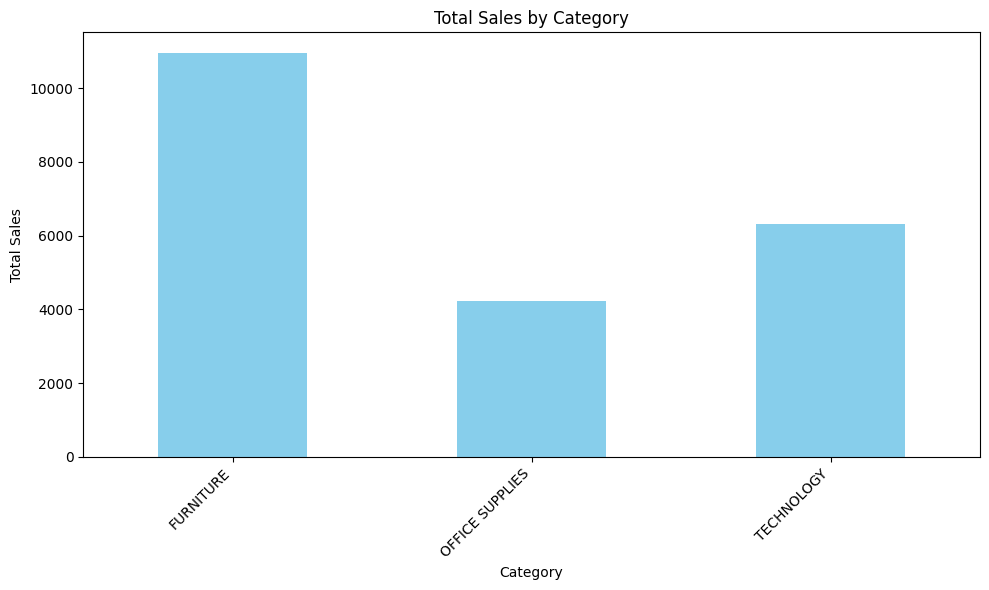

In [8]:
df['Category'] = df['Category'].str.upper()
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(10, 6))
category_sales.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

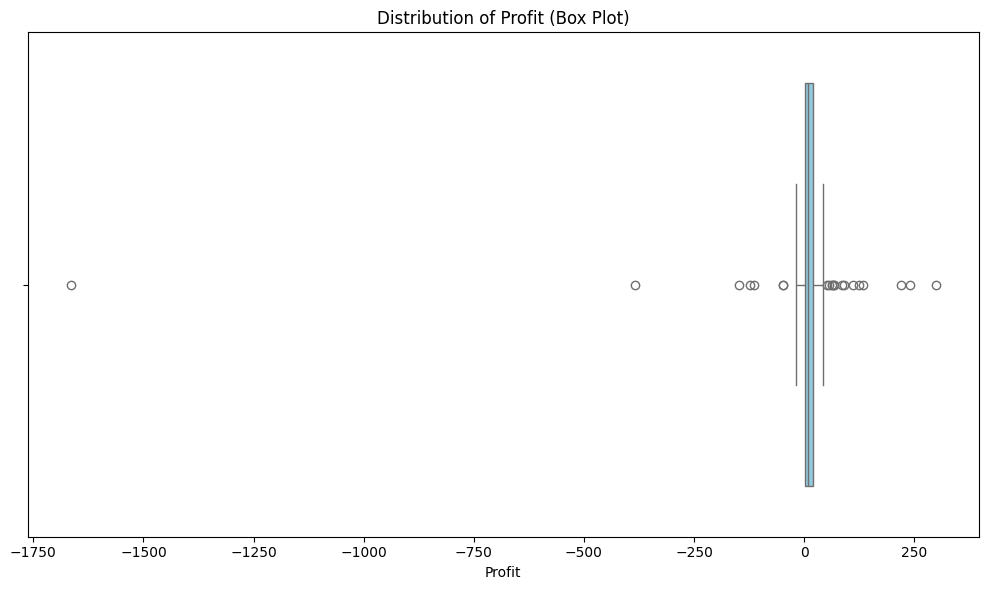

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Profit'], color='skyblue')
plt.title('Distribution of Profit (Box Plot)')
plt.xlabel('Profit')
plt.tight_layout()
plt.show()

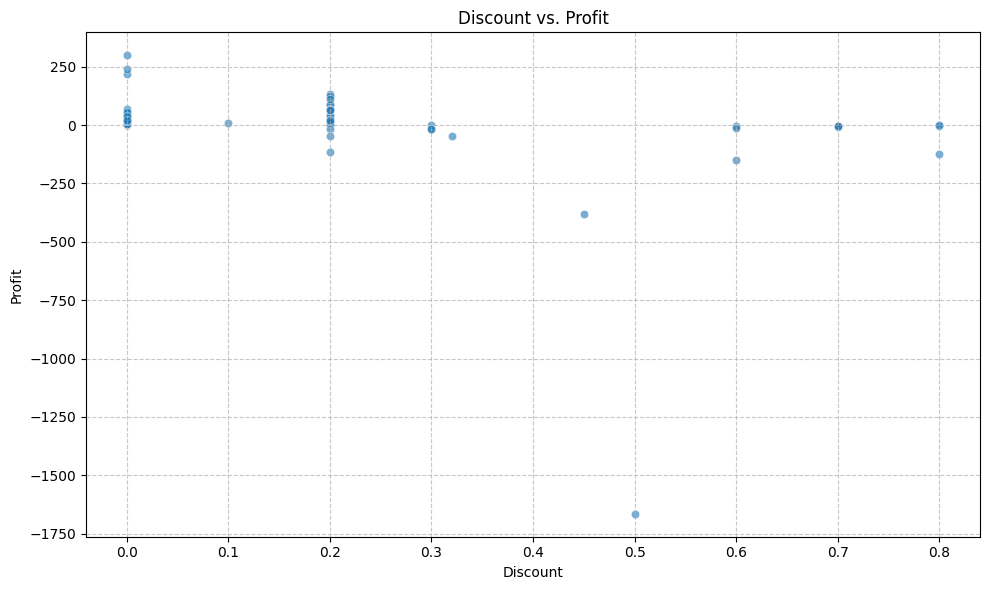

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.title('Discount vs. Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

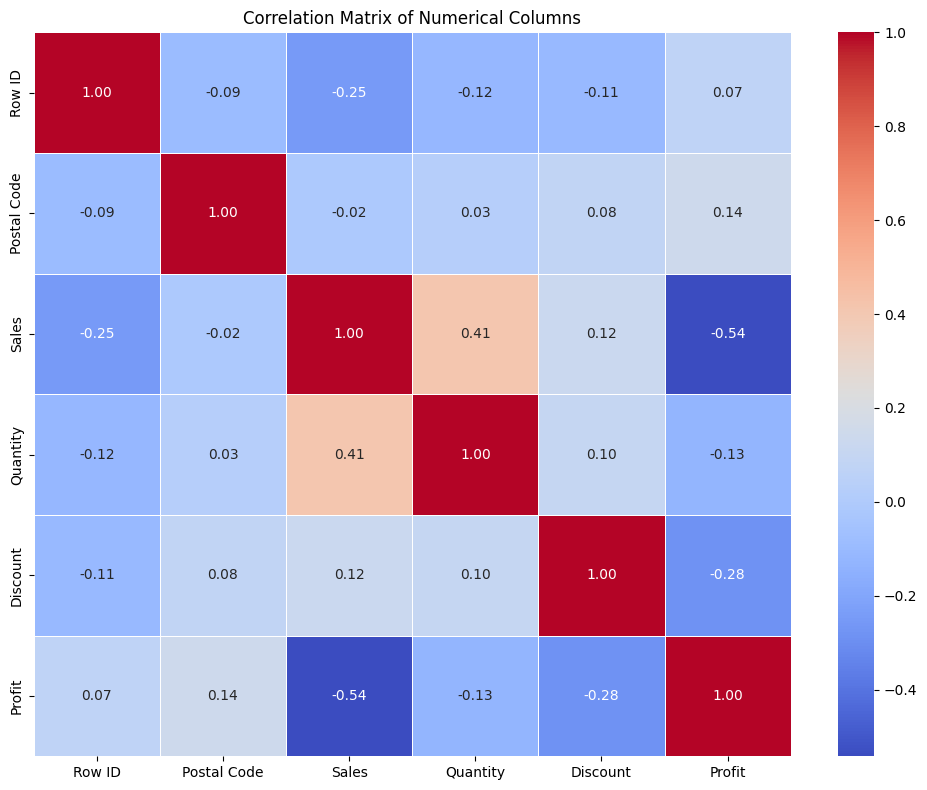

In [14]:
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Columns')
plt.tight_layout()
plt.show()

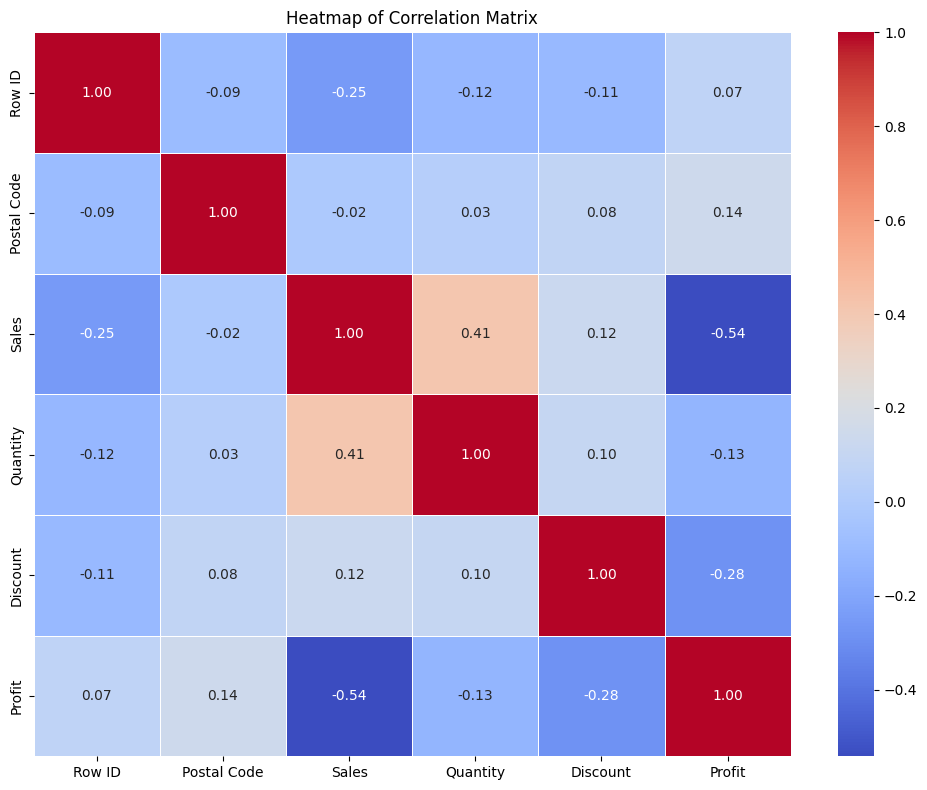

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap of Correlation Matrix')
plt.tight_layout()
plt.show()

In [22]:
category_profit = df.groupby('Category')['Profit'].sum()
highest_profit_category = category_profit.idxmax()
highest_profit_value = category_profit.max()

print(f"The category with the highest total profit is: {highest_profit_category} with a profit of {highest_profit_value:.2f}")
print("\nTotal profit by category:")
print(category_profit)

The category with the highest total profit is: TECHNOLOGY with a profit of 903.60

Total profit by category:
Category
FURNITURE         -1677.4139
OFFICE SUPPLIES     671.9193
TECHNOLOGY          903.6039
Name: Profit, dtype: float64
